In [116]:
import h5py
import os
import matplotlib.pyplot as plt
from glob import glob
from astropy.visualization import ImageNormalize, AsinhStretch, LogStretch
import matplotlib.pylab as pylab
import colorcet as cc
from astropy.coordinates import SkyCoord
from astropy.wcs.utils import proj_plane_pixel_scales
from astropy.io import fits
from astropy import units
import numpy as np
from astropy.wcs import WCS
import glob

plt.style.use("dark_background")
plt.style.use("science") # Need SciencePLots
params = {
         'axes.labelsize': 25,
         'axes.titlesize': 30,
         'ytick.labelsize' :20,
         'xtick.labelsize' :20,
         'xtick.major.size': 8,
         'xtick.minor.size': 4,
         'xtick.major.width': 1,
         'xtick.minor.width': 1,
         'ytick.color': "w",
         'xtick.color': "w",
         'axes.labelcolor': "w",
         'ytick.labelcolor' : "w",
         'xtick.labelcolor' : "w",
         }
pylab.rcParams.update(params)

def draw_scale_and_compass(ax, cutout, wcs, rotation=0, scale=1, x0=0.1, y0=0.1, compass_size=0.1, arrow_size=0.001, color="k", lw=2, textpad=5, fontsize=15):
    hdr = wcs.to_header()
    pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(wcs) # in degrees /pixels
    pixel_scale = np.mean([pixel_scale_x, pixel_scale_y]) # for drawing arrows
    M, N = cutout.shape
    
    # nice doc here http://montage.ipac.caltech.edu/docs/headers.html
    # Remember that PC maps pixels to world, so it include a mirror flip of the j coordinate (East-West)
    pc_matrix = wcs.pixel_scale_matrix
    north = np.array([1, 0])
    east = np.array([0, -1]) # accounts for the mirror flip of that coordinate to stay in pixel space
    # Using these prints, the angle of rotation should be printed has the same (+180 undo the mirror flip)
    # print(np.arctan2(pc_matrix[1, 0], pc_matrix[0, 0]) * 180 / np.pi - 90)
    # print(np.arctan2(-pc_matrix[0, 1], pc_matrix[1, 1]) * 180 / np.pi - 90 + 180)
    # Now rotate PC matrix onto our projected coordinate system. This will be useful when images are rotated by 90 degrees or 180 etc. 
    assert rotation % 90 == 0, "Rotation should only be used for images flipped by 90 or 180 degrees"
    theta = rotation * np.pi / 180 / 2 # divide by two to apply this to the PC matrix
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta), np.cos(theta)]])
    pc_matrix = R @ pc_matrix @ R.T
    
    # North arrow 
    ndx = (pc_matrix @ north)[0] * compass_size * N / pixel_scale # apply minus sign to recover the orientation of the image
    ndy = (pc_matrix @ north)[1] * compass_size * N / pixel_scale
    # East arrow
    edx = (pc_matrix @ east)[0] * compass_size * N / pixel_scale
    edy = (pc_matrix @ east)[1] * compass_size * N / pixel_scale
    # some convenient padding solutions
    nrx = -abs(ndx) / np.sqrt(ndx**2 + ndy**2) 
    nry = abs(ndy) / np.sqrt(ndx**2 + ndy**2)
    erx = edx / np.sqrt(edx**2 + edy**2)
    ery = edy / np.sqrt(edx**2 + edy**2)
    # Orientation of the letters N and E
    angle = (np.arctan2(np.abs(ndy), ndx) - np.pi / 2) * 180 / np.pi
    
    # Scale bar
    ax.plot([x0*N, x0*N + scale/pixel_scale_y/3600], [y0*M, y0*M], linewidth=lw, color=color)
    ax.text(x0*N + scale/pixel_scale_x/2/3600, y0*M+textpad/2, f"{abs(scale)}''", fontsize=fontsize, color=color, ha='center', weight='bold')

    # North arrow, on the bottom right corner, pointing up
    ax.arrow(x=(1 - x0)*N, y=y0*M, dx=ndx, dy=ndy, head_width=abs(arrow_size)*N, head_length=abs(arrow_size)*N, fc=color, ec=color, linewidth=lw)
    ax.text((1 - x0)*N+ndx+textpad*nrx, y0*M+ndy+textpad*nry, "N", color=color, fontsize=fontsize, ha='center', rotation=angle, weight='bold')
    
    # East arrow, on the bottom right corner, pointing left
    ax.arrow(x=(1 - x0)*N, y=y0*M, dx=edx, dy=edy, head_width=abs(arrow_size)*N, head_length=abs(arrow_size)*N, fc=color, ec=color, linewidth=lw)
    ax.text((1 - x0)*N+edx+4*textpad*erx/3, y0*M+edy+4*textpad*ery/3, "E", color=color, fontsize=fontsize, ha='center', rotation=angle, weight='bold')
    return ax

In [149]:
# F814W targets
TARGET = 2
coord1 = SkyCoord("9:57:56.5294", "2:27:37.963", unit=(units.hourangle, units.deg))
coord2 = SkyCoord("9:57:46.8867", "2:28:22.735", unit=(units.hourangle, units.deg))
coord3 = SkyCoord("9:57:49.1102", "2:28:19.430", unit=(units.hourangle, units.deg))
if TARGET == 1:
    data = fits.open("../data/connors_target1.fits")
    coord = coord1
if TARGET == 2:
    data = fits.open("../data/connors_target2.fits")
    coord = coord2
if TARGET == 3:
    data = fits.open("../data/connors_target3.fits")
    coord = coord3

data.info()

Filename: ../data/connors_target2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     817   ()      
  1  DRZ           1 ImageHDU        31   (64, 64)   float32   
  2  FLC           1 ImageHDU       251   (64, 64)   float64   
  3  FLC           1 ImageHDU       251   (64, 64)   float64   
  4  FLC           1 ImageHDU       251   (64, 64)   float64   
  5  FLC           1 ImageHDU       251   (64, 64)   float64   
  6  D2IMARR       1 ImageHDU        16   (64, 32)   float32   
  7  D2IMARR       2 ImageHDU        16   (64, 32)   float32   
  8  D2IMARR       3 ImageHDU        16   (64, 32)   float32   
  9  D2IMARR       4 ImageHDU        16   (64, 32)   float32   
 10  WCSDVARR      1 ImageHDU        16   (64, 32)   float32   
 11  WCSDVARR      2 ImageHDU        16   (64, 32)   float32   
 12  WCSDVARR      3 ImageHDU        16   (64, 32)   float32   
 13  WCSDVARR      4 ImageHDU        16   (64, 32)   float32   
 14  HDRLET     

In [150]:
wcs = WCS(data[1].header)

In [151]:
paths = glob.glob(f"../results/posterior_*target{TARGET}*.h5")

keys = [50, 100, 200, 1000, 3000]
sorted_paths = {key: [p for p in paths if f"guidance{key}_" in p] for key in keys}

In [152]:
hf = h5py.File(sorted_paths[50][0])
hf.keys()

<KeysViewHDF5 ['model', 'observation', 'psf', 'reconstruction']>

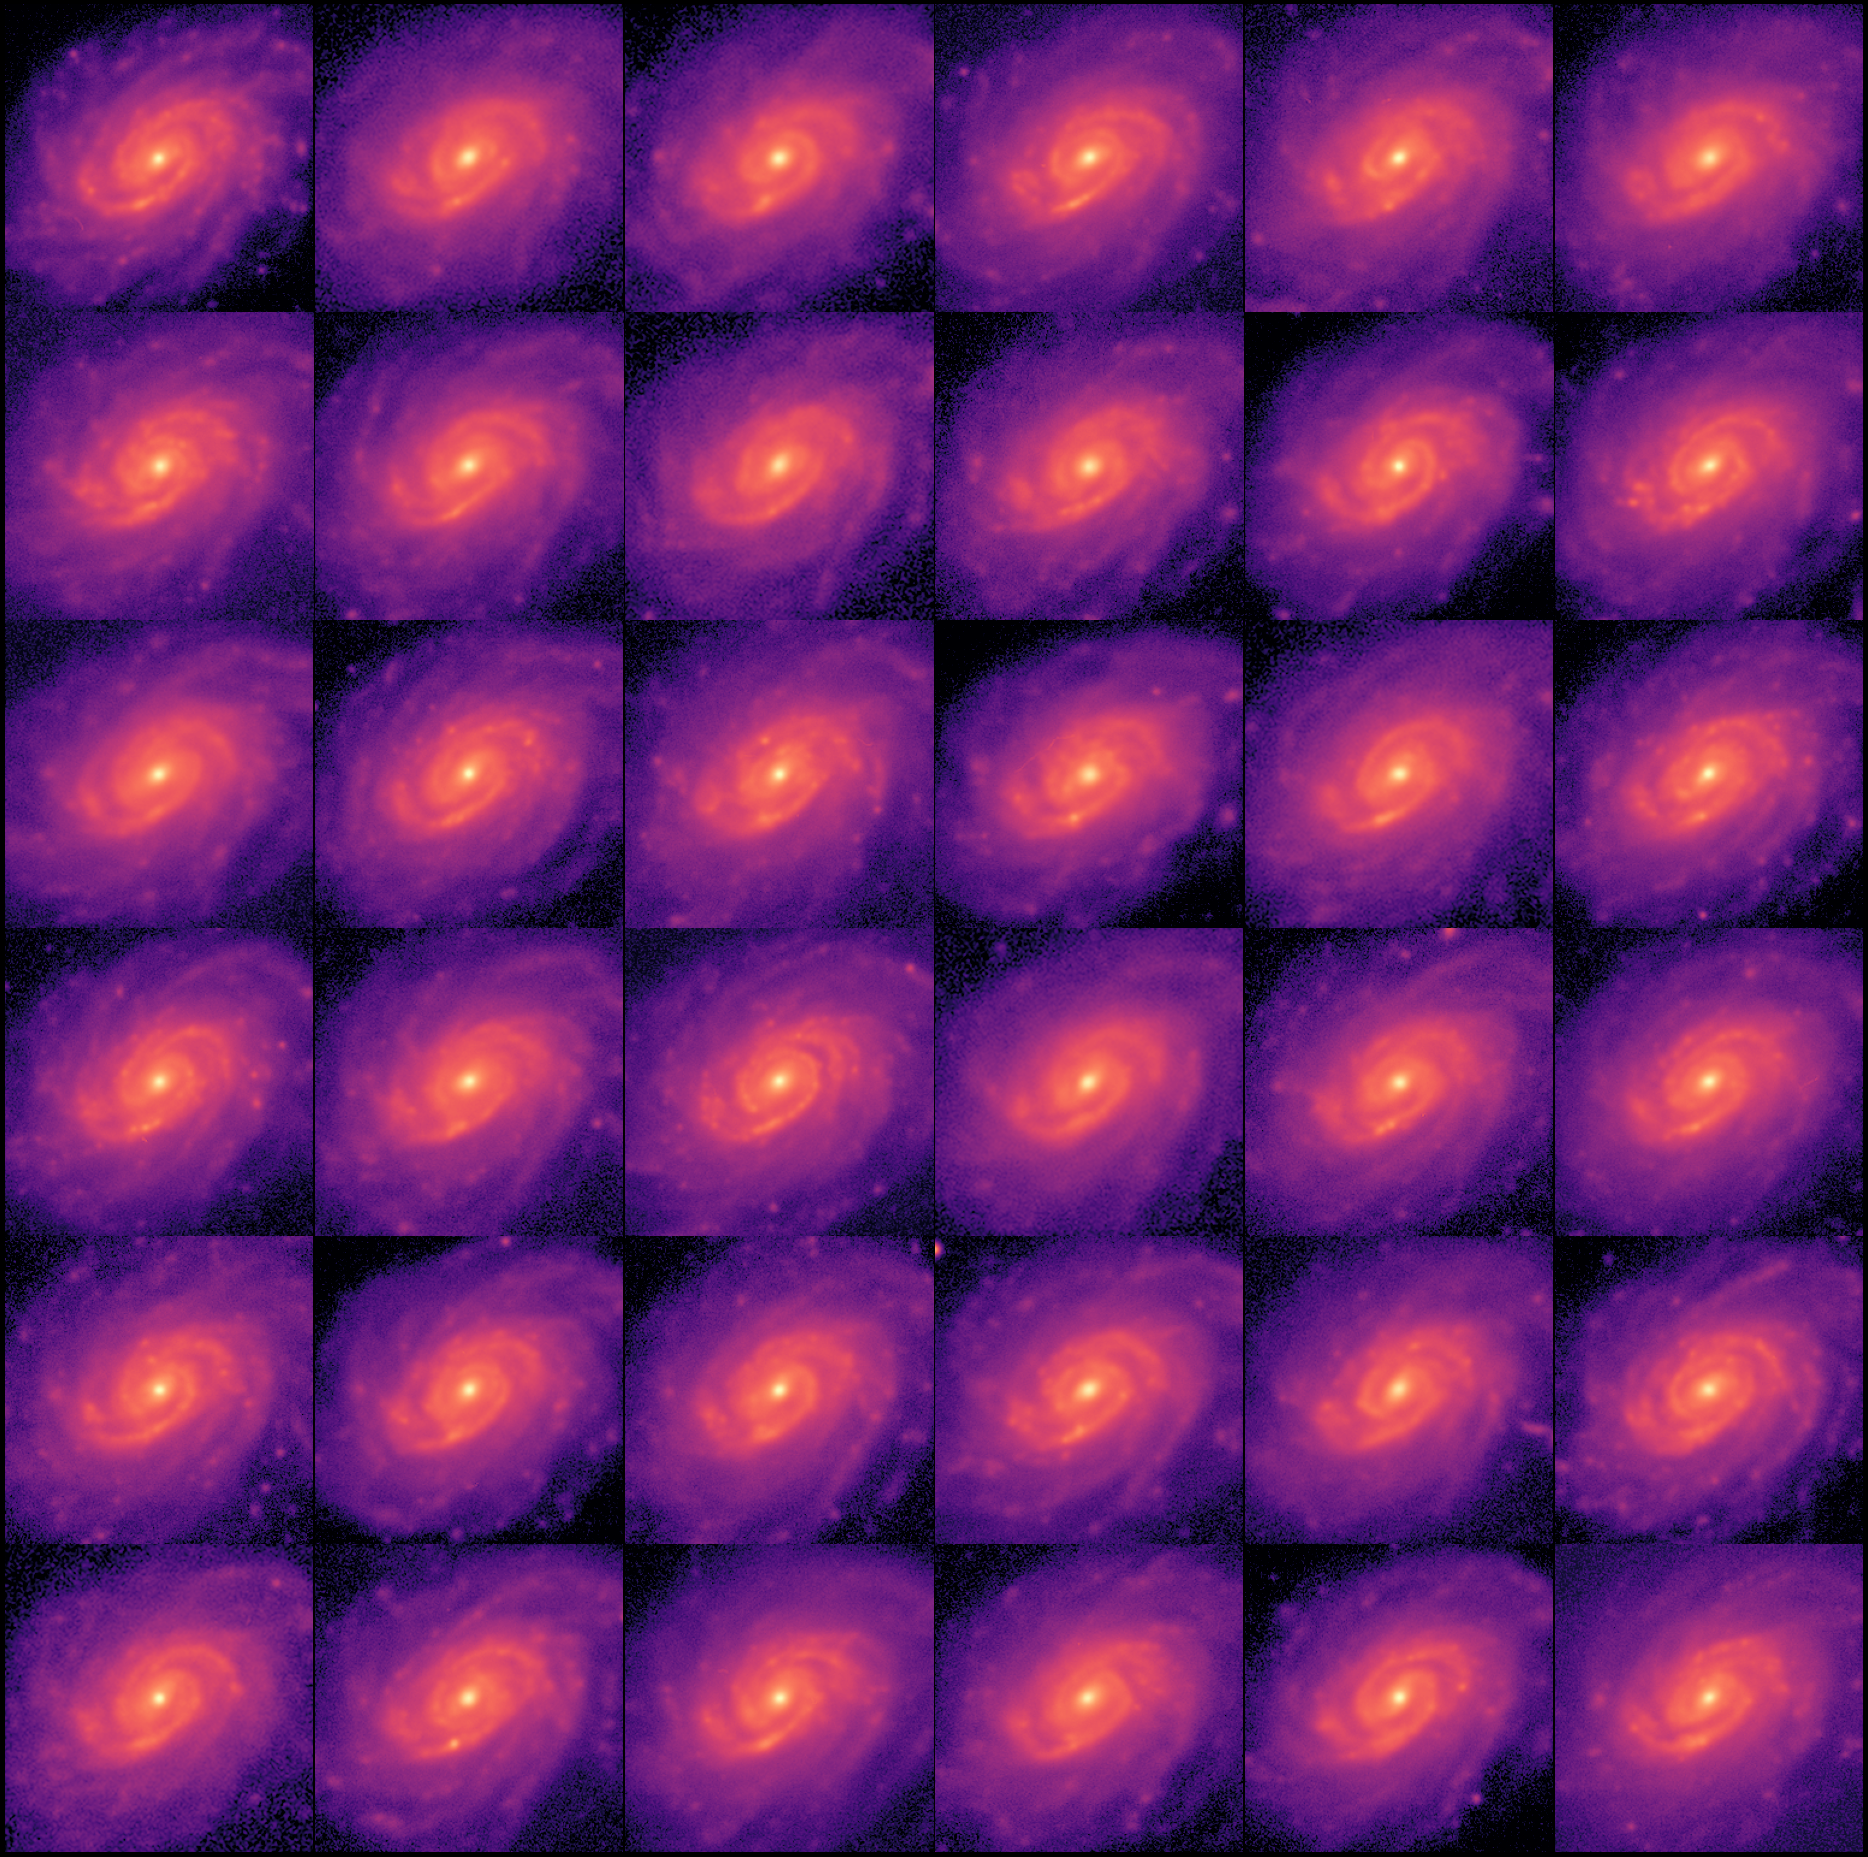

In [153]:
fig, axs = plt.subplots(6, 6, figsize=(24, 24))

for i in range(6):
    for j in range(6):
        k = i * 6 + j
        axs[i, j].imshow(hf["model"][k, 0], cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-3, vmax=1, clip=True))
        axs[i, j].axis("off")
plt.subplots_adjust(hspace=0, wspace=0)

In [154]:
mean_img = sum([h5py.File(f)["model"][:, 0].mean(axis=0) for f in sorted_paths[100]]) / len(sorted_paths[100])
std_img = np.sqrt(sum([np.sum((h5py.File(f)["model"][:, 0] - mean_img)**2, axis=0) for f in sorted_paths[100]])) / len(sorted_paths[100]) / len(sorted_paths[100][0])

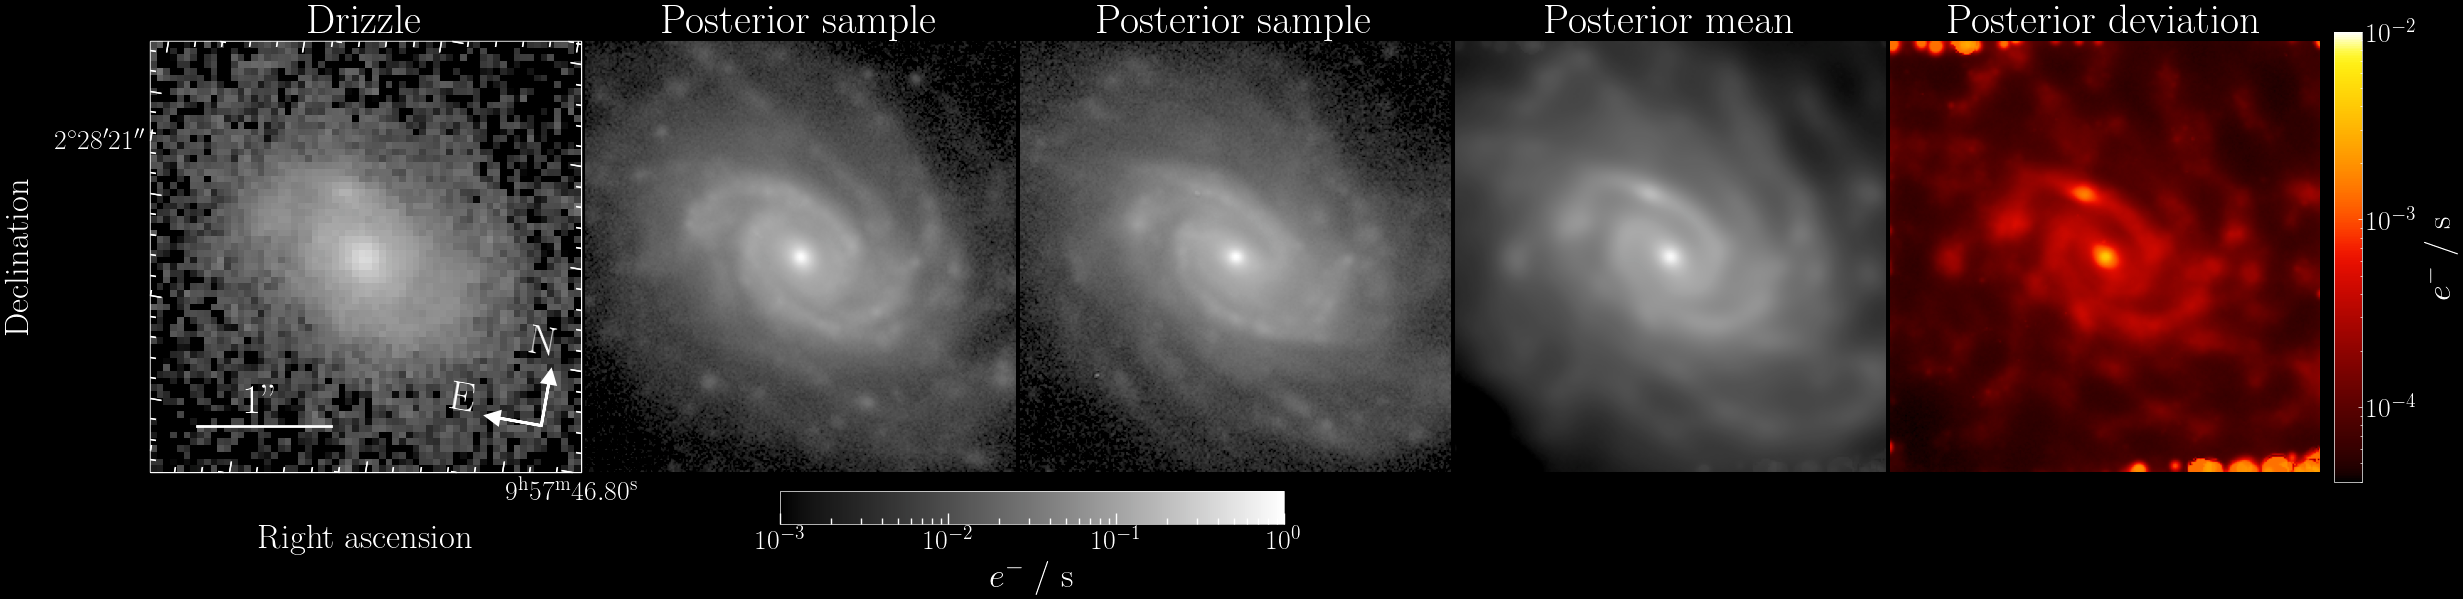

In [155]:
fig = plt.figure(figsize=(28, 6))
cmap = cc.cm["gray"]
cmap_std = cc.cm["fire"]
# cmap = "magma"
# cmap_std = "hot"
norm = plt.cm.colors.LogNorm(vmin=1e-3, vmax=1, clip=True) # change so it makes sense with your units
norm_std = plt.cm.colors.LogNorm(vmin=4e-5, vmax=1e-2, clip=True) # also change this as well

# norm = ImageNormalize(1e3*dirty_image[..., None, None].cpu().numpy(), vmin = 0, stretch = AsinhStretch())

img = data[1].data
ax = fig.add_subplot(151, projection=wcs)
im1 = ax.imshow(img, cmap=cmap, norm=norm)
draw_scale_and_compass(ax, img, wcs, scale=1, x0=0.1, y0=0.1, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=4, fontsize=30)
ax.tick_params(axis='both', which='both', color='white')
ax.set_ylabel("Declination")
ax.set_xlabel("Right ascension")
ax.set_title("Drizzle")

for i in range(2):
    k = np.random.randint(len(hf["model"]))
    img = hf["model"][k, 0]
    ax = fig.add_subplot(int(f"15{i+2}"))
    ax.imshow(img, cmap=cmap, norm=norm, origin="lower")
    ax.axis("off")
    ax.tick_params(axis='both', which='both', color='white')
    ax.set_title("Posterior sample")

# Mean image (or mode img)
ax = fig.add_subplot(int(f"154"))
ax.imshow(mean_img, cmap=cmap, norm=norm, origin="lower")
ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior mean") # or mode

# Standard deviation
ax = fig.add_subplot(int(f"155"), projection=wcs)
im2 = ax.imshow(std_img, cmap=cmap_std, norm=norm_std)
ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior deviation") # or mode

cbar_ax = fig.add_axes([0.35, 0.05, 0.18, 0.055])  # Position colorbar at [left, bottom, width, height]
cb1 = plt.colorbar(im1, cax=cbar_ax, orientation="horizontal")
cbar_ax.set_xlabel(r"$e^{-}$ / s", fontsize=25)

cbar_ax2 = fig.add_axes([0.905, 0.12, 0.01, 0.75])
fig.colorbar(im2, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"$e^{-}$ / s", fontsize=25)

plt.subplots_adjust(hspace=0, wspace=0.01)

plt.savefig(f"../results/summary_connor_target{TARGET}_probes_oldslic.png", bbox_inches="tight")

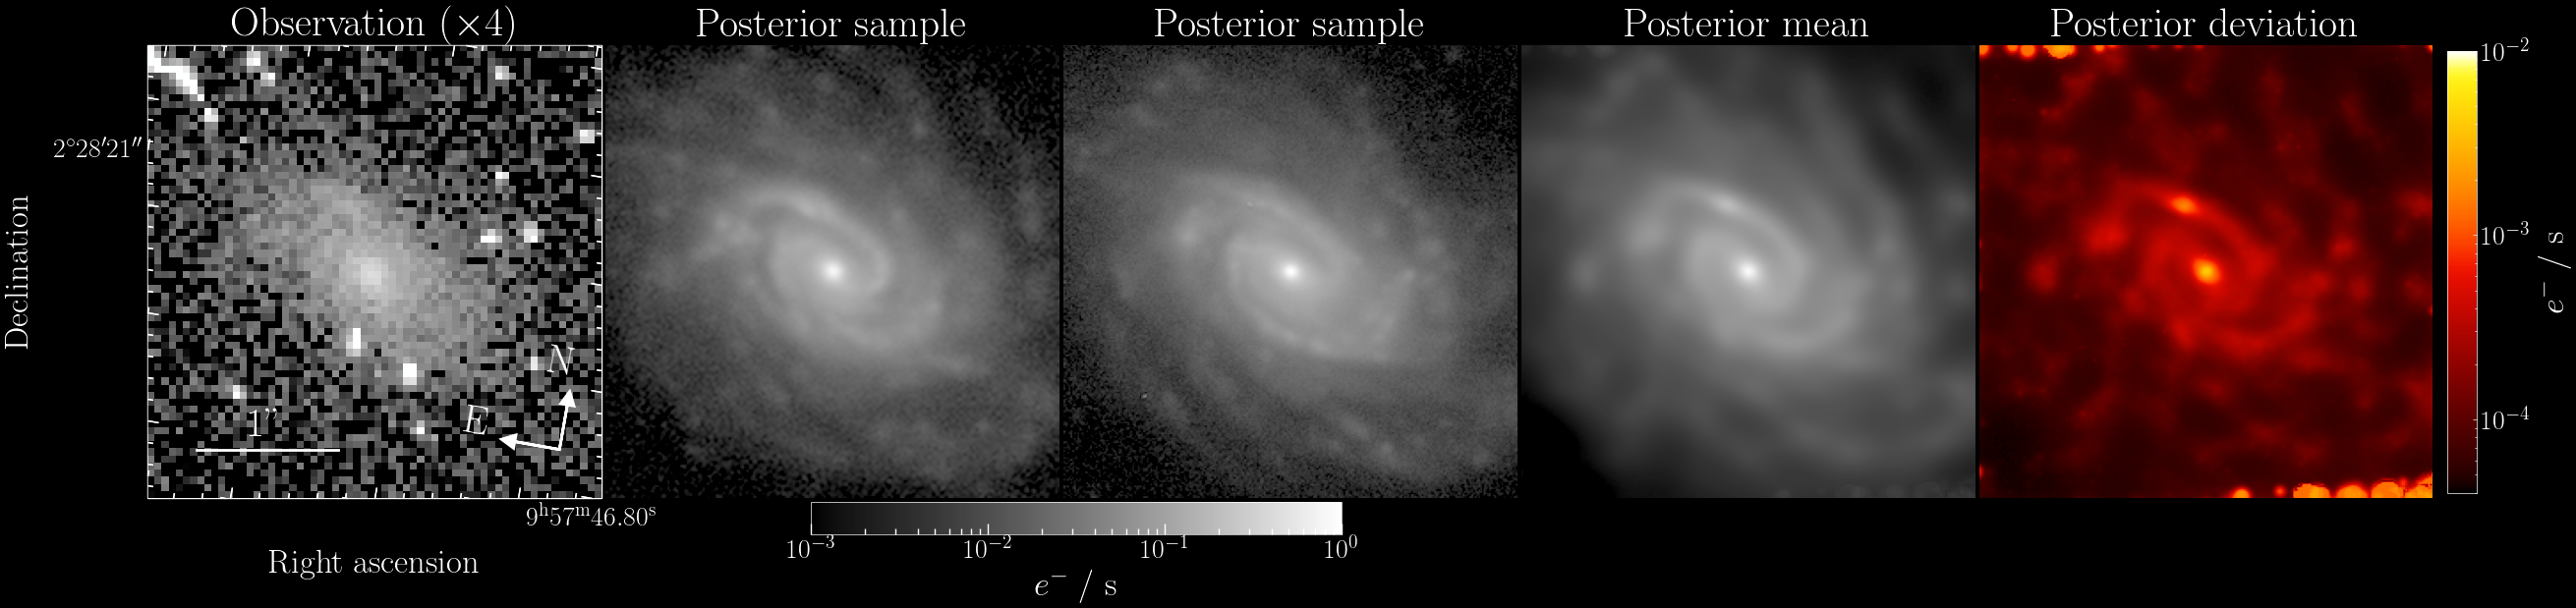

In [156]:
fig = plt.figure(figsize=(30, 6))
cmap = cc.cm["gray"]
cmap_std = cc.cm["fire"]
# cmap = "magma"
# cmap_std = "hot"
norm = plt.cm.colors.LogNorm(vmin=1e-3, vmax=1, clip=True) # change so it makes sense with your units
norm_std = plt.cm.colors.LogNorm(vmin=4e-5, vmax=1e-2, clip=True) # also change this as well

# norm = ImageNormalize(1e3*dirty_image[..., None, None].cpu().numpy(), vmin = 0, stretch = AsinhStretch())

img = data[4].data
ax = fig.add_subplot(151, projection=wcs)
im1 = ax.imshow(img, cmap=cmap, norm=norm)
draw_scale_and_compass(ax, img, wcs, scale=1, x0=0.1, y0=0.1, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=4, fontsize=30)
ax.tick_params(axis='both', which='both', color='white')
ax.set_ylabel("Declination")
ax.set_xlabel("Right ascension")
ax.set_title(r"Observation ($\times 4$)")

for i in range(2):
    k = np.random.randint(len(hf["model"]))
    img = hf["model"][k, 0]
    ax = fig.add_subplot(int(f"15{i+2}"))
    ax.imshow(img, cmap=cmap, norm=norm, origin="lower")
    ax.axis("off")
    ax.tick_params(axis='both', which='both', color='white')
    ax.set_title("Posterior sample")

# Mean image (or mode img)
ax = fig.add_subplot(int(f"154"))
ax.imshow(mean_img, cmap=cmap, norm=norm, origin="lower")
ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior mean") # or mode

# Standard deviation
ax = fig.add_subplot(int(f"155"), projection=wcs)
im2 = ax.imshow(std_img, cmap=cmap_std, norm=norm_std)
ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior deviation") # or mode

cbar_ax = fig.add_axes([0.35, 0.05, 0.18, 0.055])  # Position colorbar at [left, bottom, width, height]
cb1 = plt.colorbar(im1, cax=cbar_ax, orientation="horizontal")
cbar_ax.set_xlabel(r"$e^{-}$ / s", fontsize=25)

cbar_ax2 = fig.add_axes([0.905, 0.12, 0.01, 0.75])
fig.colorbar(im2, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"$e^{-}$ / s", fontsize=25)

plt.subplots_adjust(hspace=0, wspace=0.01)

plt.savefig(f"../results/summary2_connor_target{TARGET}_probes_oldslic.png", bbox_inches="tight")

# Temporary solution for SMACS

TODO: fixe the orientation, I have to use a fiducial orientation of -24, not 24 to get the right thing, and then rotation by 90 degrees. 

In [11]:
coord1 = SkyCoord("7:23:24.5462", "-73:27:20.172", unit=(units.hourangle, units.deg))
coord2 = SkyCoord("7:23:22.0805", "-73:27:24.575", unit=(units.hourangle, units.deg))
coord3 = SkyCoord("7:23:20.7483", "-73:26:07.203", unit=(units.hourangle, units.deg))


coord = coord2

import sys
sys.path.append("../scripts")
from forward_model import make_wcs

In [12]:
data = np.load("../results/smacs2_temp_solutions_vp_probes_prior.npz")

In [13]:
post_samples = data["sol"]
# observations = data["observations"]
y_hat = data["y_hat"] # reconstructions

In [35]:
target = 2
FILTER = "F105W"
paths = glob.glob(f"../data/smacs*target{target}*{FILTER.upper()}*.fits")
data = []
for p in paths:
    data.append(fits.open(p))

In [106]:
jwst_cutout = fits.open("../data/smacs_jwst_i2d_target2_F115W.fits")
# jwst_cutout = fits.open("../data/smacs_jwst_i2d_target2_F150W.fits")

wcs = WCS(jwst_cutout[1].header)
jwst_img = jwst_cutout[1].data

Set OBSGEO-B to   -35.798119 from OBSGEO-[XYZ].
Set OBSGEO-H to 1718363271.862 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


In [107]:
# hdr = wcs.to_header()
# hdr["CDELT1"] = 1
# hdr["CDELT2"] = 1
# wcs = WCS(hdr)

In [108]:
# jwst_cutout[1].header

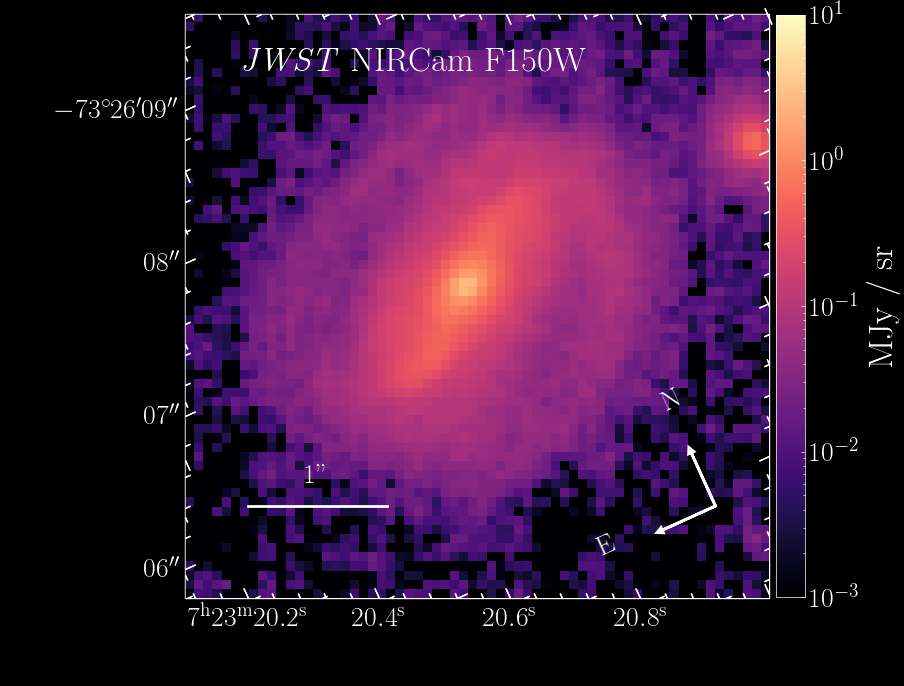

In [109]:
plt.figure(figsize=(8, 8))
plt.subplot(projection=wcs)
plt.imshow(jwst_img, cmap="magma", norm=plt.cm.colors.LogNorm(vmin=1e-3, vmax=10, clip=True))
plt.colorbar(fraction=0.047, label=r"MJy / sr", pad=0.01)
ax = plt.gca()
draw_scale_and_compass(ax, jwst_img, wcs, rotation=90, scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.01, color="w", lw=2, textpad=5, fontsize=20)
plt.annotate(r"\textit{JWST} NIRCam F150W", xy=(0.1, 0.9), xycoords="axes fraction", fontsize=25)

# Set the color of the tick labels
for tick in ax.get_xticklabels():
    tick.set_color("white")
for tick in ax.get_yticklabels():
    tick.set_color("white")

# Set the color of the axis labels
ax.set_ylabel("Declination", color='black')
ax.set_xlabel("Right ascension", color='black')

plt.ylabel("Declination")
plt.xlabel("Right ascension")

plt.savefig("jwst_f150w_ref_profile.jpg")

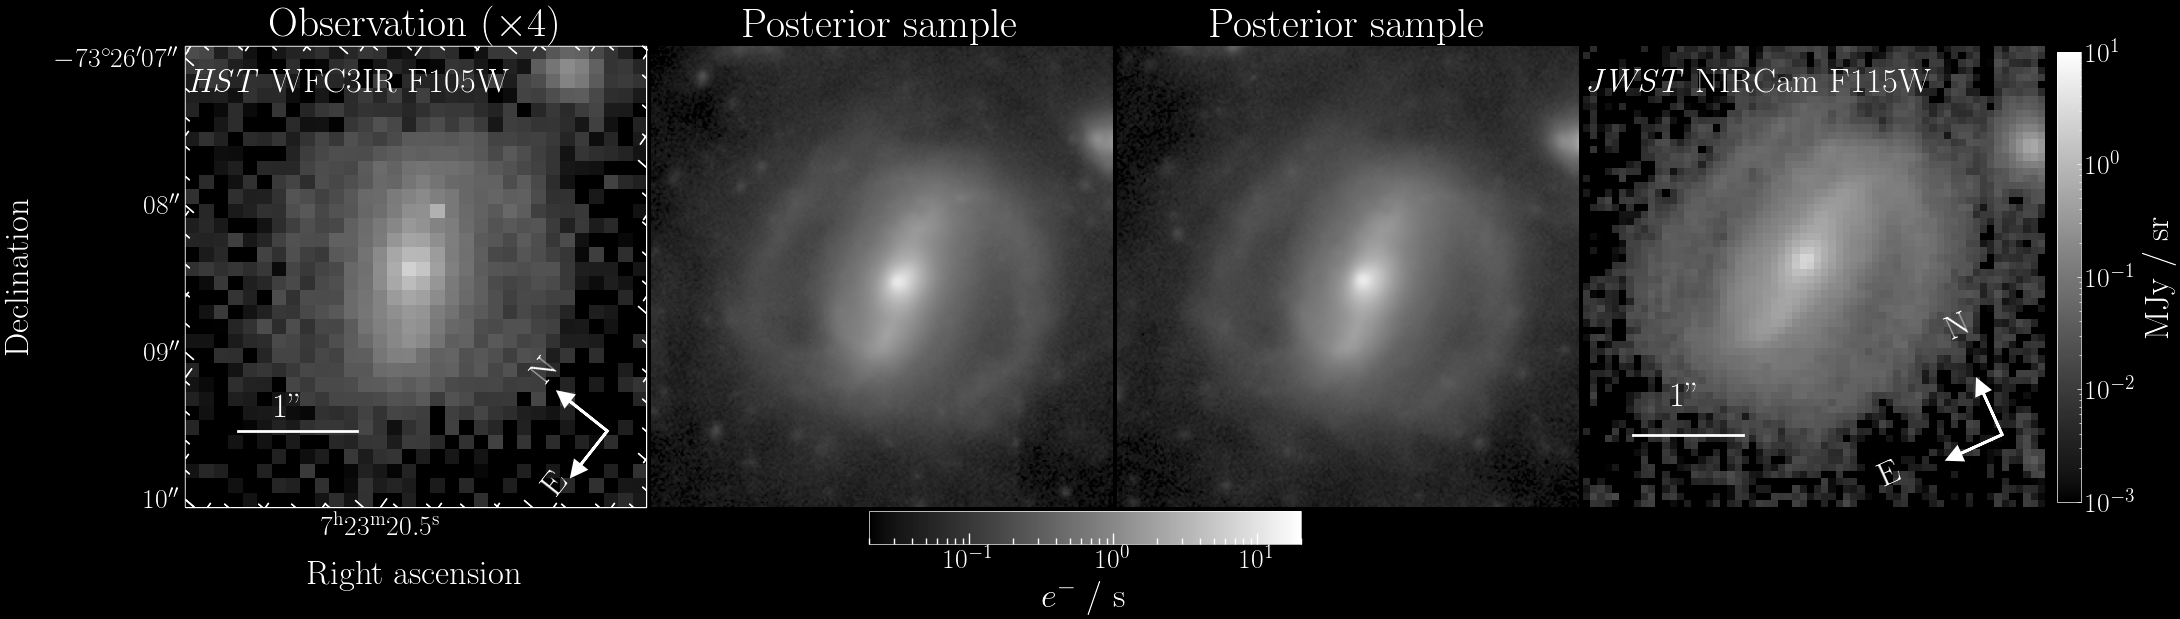

In [111]:
fig = plt.figure(figsize=(24, 6))

jwst_cmap = cc.cm["gray"]
# cmap_std = cc.cm["fire"]
cmap = cc.cm["gray"]
cmap_std = "hot"
norm = plt.cm.colors.LogNorm(vmin=2e-2, vmax=20, clip=True) # change so it makes sense with your units
jwst_norm = plt.cm.colors.LogNorm(vmin=1e-3, vmax=10, clip=True) # change so it makes sense with your units

norm_std = plt.cm.colors.LogNorm(vmin=4e-5, vmax=1e-2, clip=True) # also change this as well

# norm = ImageNormalize(1e3*dirty_image[..., None, None].cpu().numpy(), vmin = 0, stretch = AsinhStretch())

# img = observations[0, 0]#data[2].data

data_wcs = WCS(data[2][1].header, data[2])
img = np.rot90(data[2][1].data, k=1)
ax = fig.add_subplot(141, projection=data_wcs)
im1 = ax.imshow(img, cmap=cmap, norm=norm)
draw_scale_and_compass(ax, img, data_wcs,  scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=2, fontsize=25)
ax.tick_params(axis='both', which='both', color='white')
ax.set_ylabel("Declination")
ax.set_xlabel("Right ascension")
ax.annotate(r"\textit{HST} WFC3IR F105W", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=25)
ax.set_title(r"Observation ($\times 4$)")



img = np.rot90(post_samples[1, 0], k=-1)
ax = fig.add_subplot(int(f"14{2}"))
ax.imshow(img, cmap=cmap, norm=norm, origin="lower")
ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior sample")

img = np.rot90(post_samples[2, 0], k=-1)
ax = fig.add_subplot(int(f"14{3}"))
im = ax.imshow(img, cmap=cmap, norm=norm, origin="lower")
ax.axis("off")
ax.tick_params(axis='both', which='both', color='white')
ax.set_title("Posterior sample")


ax = fig.add_subplot(144, projection=wcs)
im1 = ax.imshow(jwst_img, cmap=jwst_cmap, norm=jwst_norm, origin="lower")
draw_scale_and_compass(ax, jwst_img, wcs, rotation=90, scale=1, x0=0.1, y0=0.15, compass_size=0.1, arrow_size=0.03, color="w", lw=2, textpad=8, fontsize=25)
# ax.tick_params(axis='both', which='both', color='white')
ax.axis("off")
# ax.set_ylabel("Declination")
# ax.set_xlabel("Right ascension")
ax.annotate(r"\textit{JWST} NIRCam F115W", xy=(0.01, 0.9), xycoords="axes fraction", fontsize=25)
# plt.colorbar(im, ax=ax, frac)


cbar_ax = fig.add_axes([0.41, 0.05, 0.18, 0.055])  # Position colorbar at [left, bottom, width, height]
cb1 = plt.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar_ax.set_xlabel(r"$e^{-}$ / s", fontsize=25)

cbar_ax2 = fig.add_axes([0.905, 0.12, 0.01, 0.75])
fig.colorbar(im1, cax=cbar_ax2)
cbar_ax2.set_ylabel(r"MJy / sr", fontsize=25)

plt.subplots_adjust(hspace=0, wspace=0.01)

plt.savefig(f"../results/smacs2_summary_results_temp.png", bbox_inches="tight")

In [103]:
pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(wcs) # in degrees /pixels
pixel_scale_y * jwst_img.shape[0] * 3600

3.9969220368022054

In [100]:
pixel_scale_x, pixel_scale_y = proj_plane_pixel_scales(data_wcs) # in degrees /pixels
pixel_scale_y * data[2][1].data.shape[0] * 3600

3.8700813448099716

In [105]:
pixel_scale_x

8.673875947921453e-06